# VAE baseline
This notebook is a baseline VAE model on colored mnist

In [ ]:
from vae_project.imports import *
from vae_project.dataset import *
from vae_project.utils import *
from vae_project.train.hooks import *
from vae_project.train.losses import elbo_loss
from vae_project import Trainer, get_dataset, VAE

We create list of transforms and pass them to dataloaders to speed up computations by performing them on batches instead of single images.

2 main transforms are:
- `Pad` to convert 28x28 images to 32x32 images to match decoder output without hard indexing
- `Colorize` is a custom transform that gives color to mnist images depending on `color_type` parameter 

In [ ]:
train_ds, val_ds = get_dataset("../data"), get_dataset('../data', train=False)

bs = 32
batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('label')]
collate_fn = CollateWithTransforms(batch_tfms)

In [ ]:
train_dl = DataLoader(train_ds, bs, collate_fn=collate_fn)
val_dl = DataLoader(val_ds, bs*2, collate_fn=collate_fn)
xb, yb = next(iter(train_dl))

<Axes: >

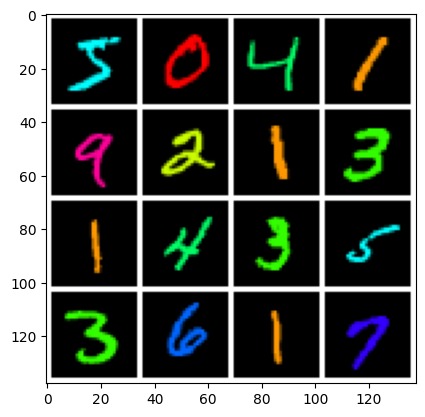

In [ ]:
show_imgs(xb[:16])

The function below is used for quick hyperparameters changes. Defaults here are somewhat optimal I found.

In [ ]:
def init_trainer(
    train_ds, val_ds, epochs=25, seed=42, batch_size=64, lr=1e-3, beta_steps=4000, batch_tfms: list = None, in_channels=3
):
    random_seed(seed)
    bs = batch_size
    latent_dim = 16
    h_dim = 64
    wd = 1e-4
    channels = (in_channels, 32, 64, 128)
    collate_fn = CollateWithTransforms(batch_tfms or [])

    dl_kwargs = dict(collate_fn=collate_fn, num_workers=6, persistent_workers=True)
    train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, **dl_kwargs)
    val_dl = DataLoader(val_ds, batch_size=bs * 4, **dl_kwargs)

    model = VAE(channels, input_size=(32, 32), latent_dim=latent_dim, h_dim=h_dim)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    hooks = [VAEMetricsHook(recon_loss_fn="bce"), ProgressBarHook(), BetaSchedulerHook(beta_steps)]

    trainer = Trainer(model, train_dl, val_dl, optimizer, partial(elbo_loss, recon="bce"), epochs=epochs, hooks=hooks)
    return trainer

In [ ]:
trainer = init_trainer(train_ds, val_ds, batch_tfms=batch_tfms)
trainer.fit()

Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/25 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/25 | Train Loss: 293.0398 | Val Loss: 191.4371


Epoch 2/25 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 24/25 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 173.4380 | Val Loss: 175.4611


Epoch 25/25 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 25/25 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss: 173.1186 | Val Loss: 175.4009


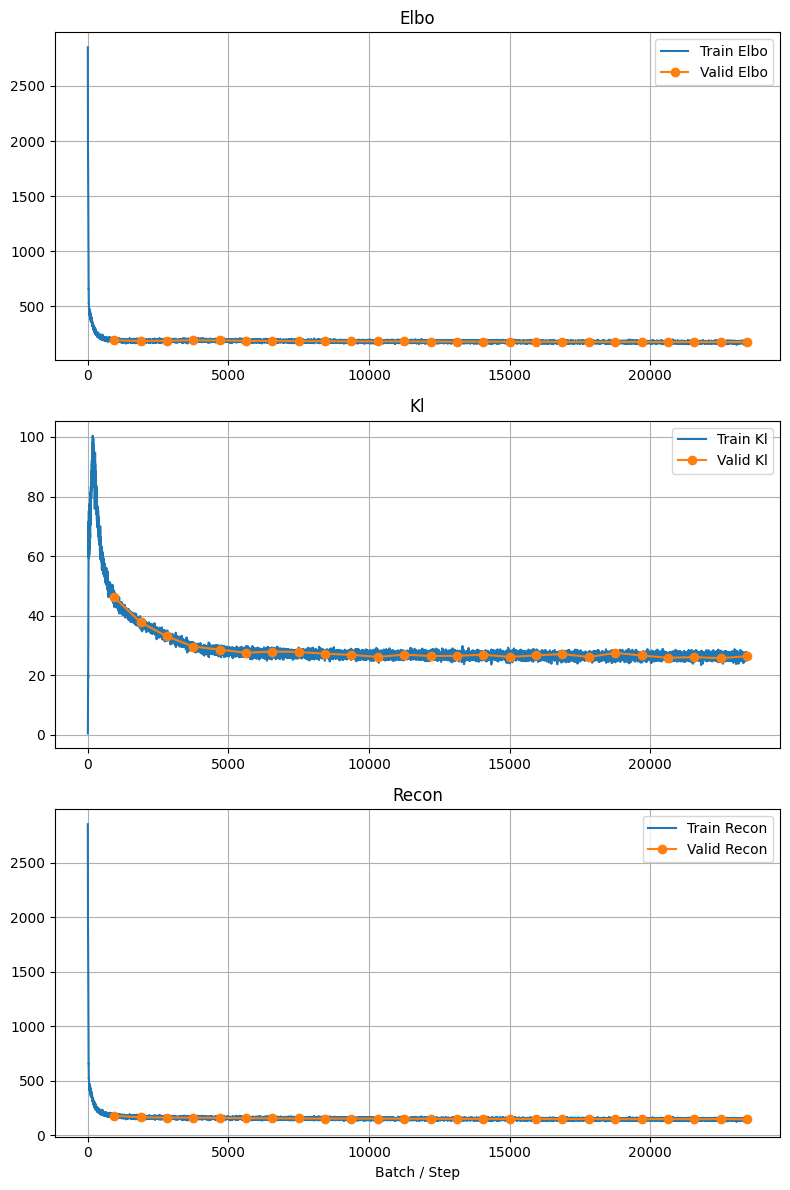

In [ ]:
trainer.get_hook(MetricsHook).plot_loss()

Text(0.5, 1.0, 'Inputs')

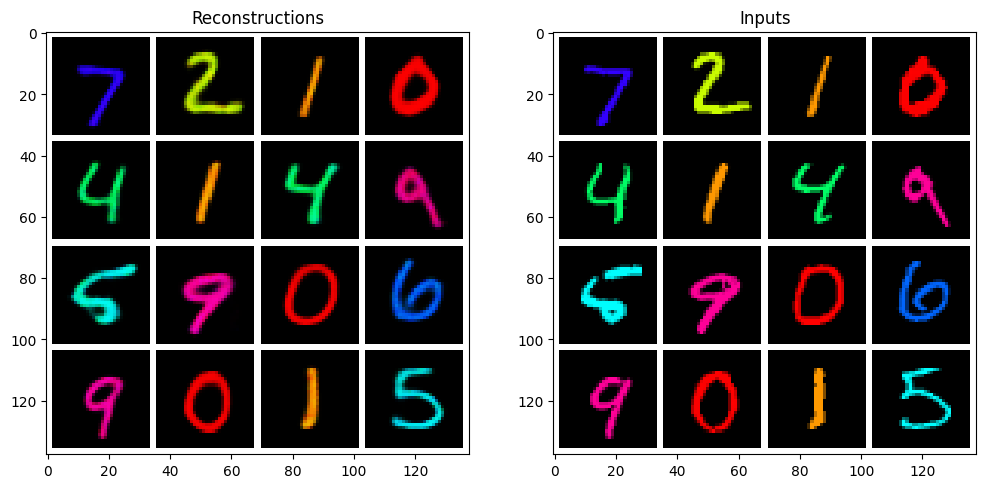

In [ ]:
xb, _ = next(iter(trainer.valid_dl))
x = xb[:16]
recon, *_ = trainer.predict(x)
axes = plt.subplots(ncols=2, figsize=(12,8))[1]
show_imgs(recon, axes[0])
axes[0].set_title('Reconstructions')
show_imgs(x, axes[1])
axes[1].set_title('Inputs')

### Samples

<Axes: >

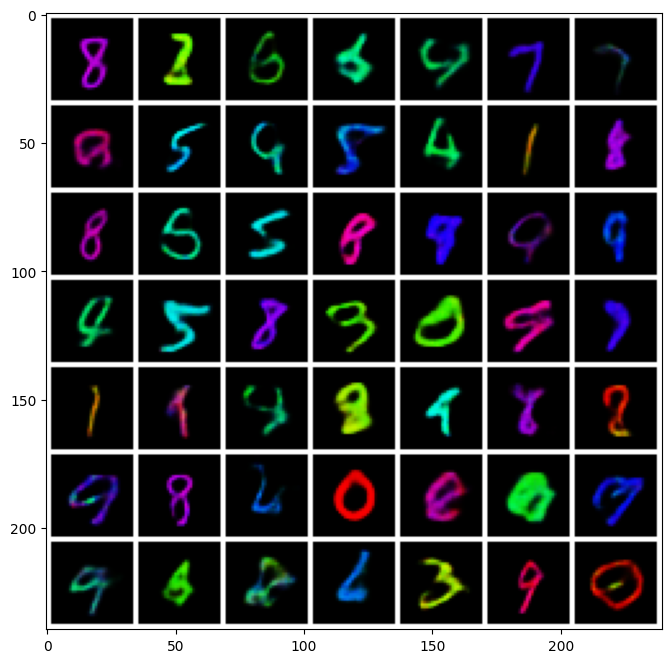

In [ ]:
ax = plt.subplots(figsize=(8,8))[1]
show_imgs(trainer.model.sample(49), ax=ax)

## Random colors

In [ ]:
batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('random')]
trainer = init_trainer(train_ds, val_ds, 30, batch_tfms=batch_tfms)
trainer.fit()

Epoch:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/30 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 310.4908 | Val Loss: 204.9752


Epoch 2/30 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 29/30 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 181.8677 | Val Loss: 183.2516


Epoch 30/30 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 30/30 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 181.4656 | Val Loss: 182.3180


Text(0.5, 1.0, 'Inputs')

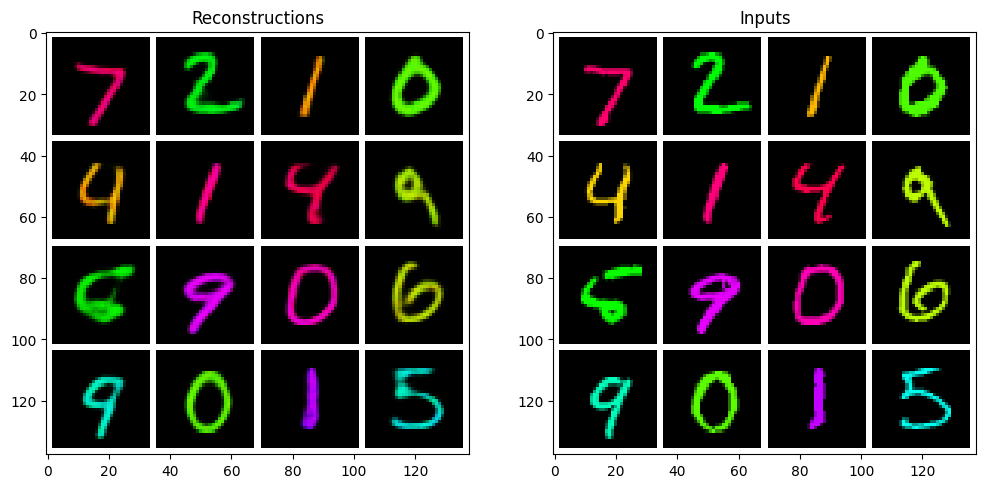

In [ ]:
xb, _ = next(iter(trainer.valid_dl))
x = xb[:16]
recon, *_ = trainer.predict(x)
axes = plt.subplots(ncols=2, figsize=(12,8))[1]
show_imgs(recon, axes[0])
axes[0].set_title('Reconstructions')
show_imgs(x, axes[1])
axes[1].set_title('Inputs')

<Axes: >

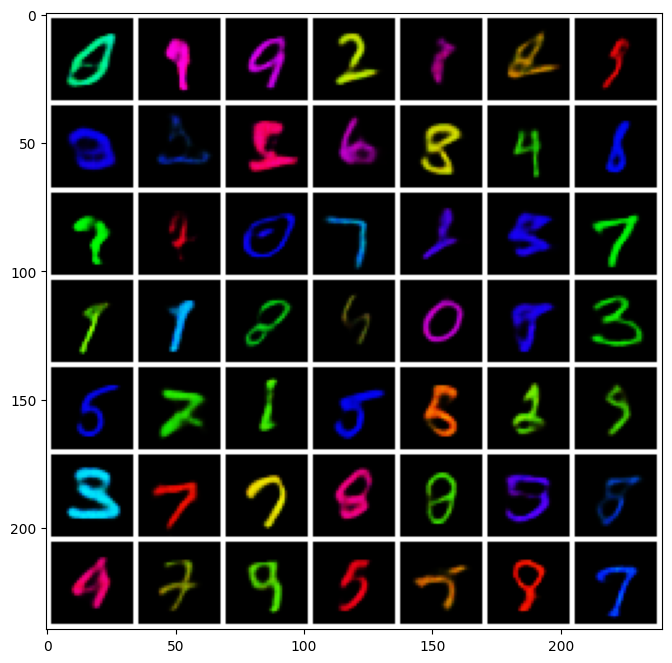

In [ ]:
ax = plt.subplots(figsize=(8,8))[1]
show_imgs(trainer.model.sample(49), ax=ax)

## Less colors

In [ ]:
batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('random_discrete', 4)]
trainer = init_trainer(train_ds, val_ds, 30, batch_tfms=batch_tfms)
trainer.fit()

Epoch:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/30 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 281.9913 | Val Loss: 177.4389


Epoch 2/30 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 29/30 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 153.9359 | Val Loss: 155.7134


Epoch 30/30 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 30/30 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 153.7853 | Val Loss: 154.4847


Text(0.5, 1.0, 'Inputs')

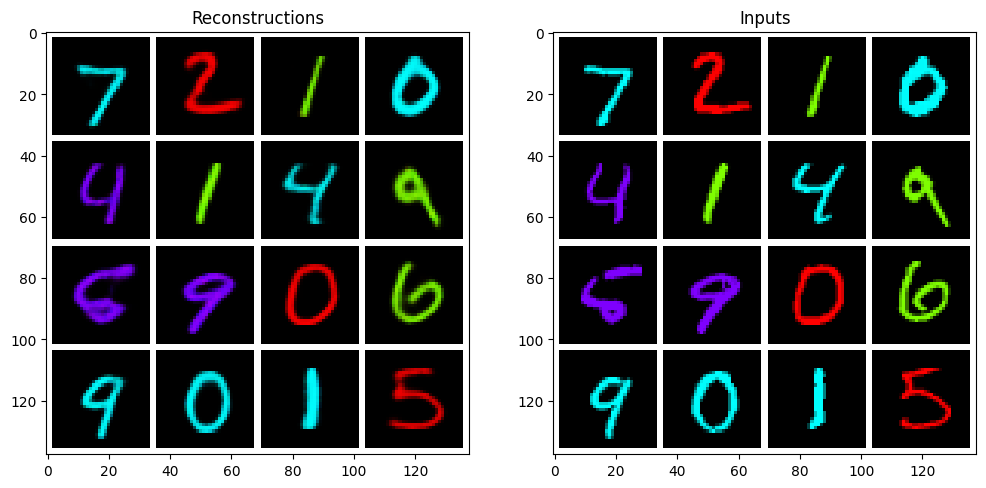

In [ ]:
xb, _ = next(iter(trainer.valid_dl))
x = xb[:16]
recon, *_ = trainer.predict(x)
axes = plt.subplots(ncols=2, figsize=(12,8))[1]
show_imgs(recon, axes[0])
axes[0].set_title('Reconstructions')
show_imgs(x, axes[1])
axes[1].set_title('Inputs')

<Axes: >

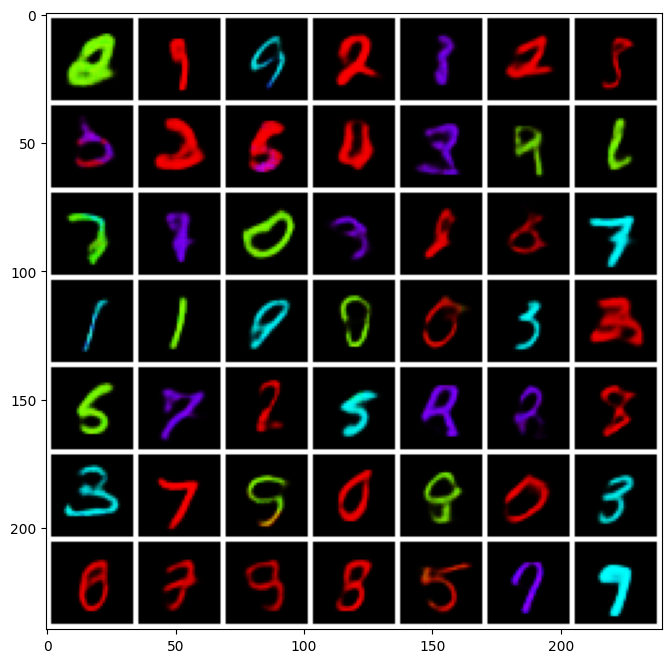

In [ ]:
ax = plt.subplots(figsize=(8,8))[1]
show_imgs(trainer.model.sample(49), ax=ax)

## Single color (MNIST)

In [ ]:
batch_tfms = [ToBatchTransform(tv.transforms.Pad(2))]
trainer = init_trainer(train_ds, val_ds, batch_tfms=batch_tfms, in_channels=1)
trainer.fit()

Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/25 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/25 | Train Loss: 127.3855 | Val Loss: 97.8736


Epoch 2/25 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 24/25 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 97.3914 | Val Loss: 98.2442


Epoch 25/25 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 25/25 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss: 97.1965 | Val Loss: 97.3859


In [ ]:
batch_tfms = [ToBatchTransform(tv.transforms.Pad(2))]
trainer = init_trainer(train_ds, val_ds, batch_tfms=batch_tfms, in_channels=1)
trainer.fit()

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/20 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 139.4908 | Val Loss: 107.9552


Epoch 2/20 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 19/20 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 100.0630 | Val Loss: 100.5043


Epoch 20/20 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 20/20 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 99.8234 | Val Loss: 100.6166


Text(0.5, 1.0, 'Inputs')

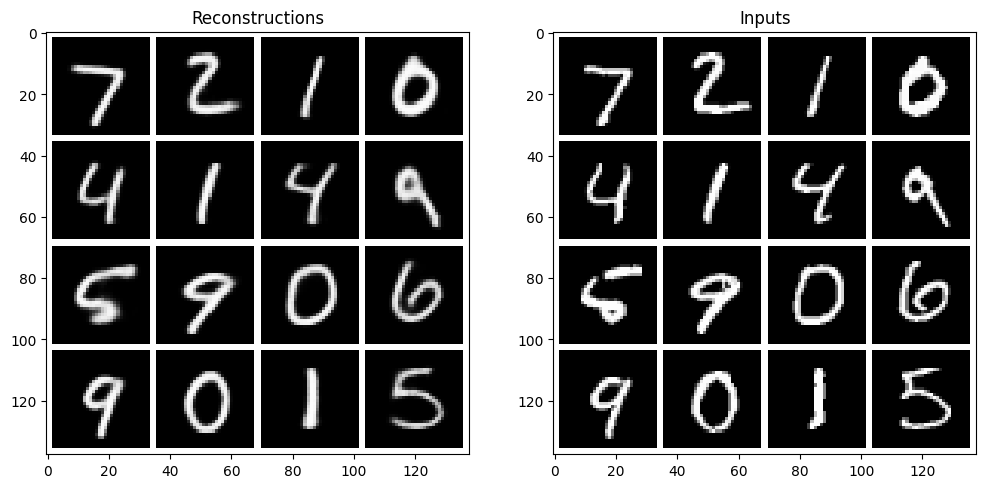

In [ ]:
xb, _ = next(iter(trainer.valid_dl))
x = xb[:16]
recon, *_ = trainer.predict(x)
axes = plt.subplots(ncols=2, figsize=(12,8))[1]
show_imgs(recon, axes[0])
axes[0].set_title('Reconstructions')
show_imgs(x, axes[1])
axes[1].set_title('Inputs')

<Axes: >

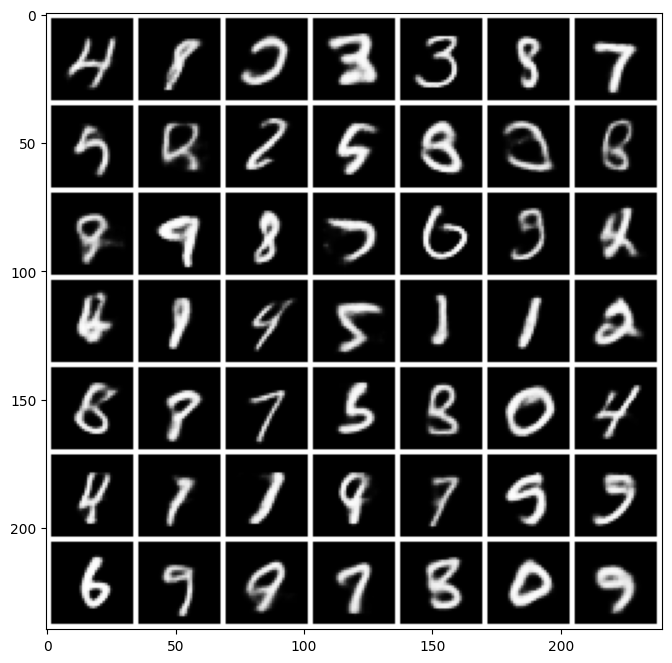

In [ ]:
ax = plt.subplots(figsize=(8,8))[1]
show_imgs(normalize_img(trainer.model.sample(49)), ax=ax)